# Milestone 4: Final Model Pipeline

**Course:** CS 1090B

**Canvas Project Number:** 25

**Group Members:** Sam Chung, Anthony Shen, Lewis Tu, Allie Zong

## EDA Recap
These plots summarize the patterns that matter most for the hourly LSTM pipeline: calendar structure, demand signal, seasonality, and lag dependence.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

eda = pd.read_csv("initial_data.csv")
eda["datetime_beginning_ept"] = pd.to_datetime(eda["datetime_beginning_ept"])
eda = eda.sort_values("datetime_beginning_ept").set_index("datetime_beginning_ept")

eda["hour"] = eda.index.hour
eda["day_of_week"] = eda.index.dayofweek
eda["month"] = eda.index.month
eda["is_weekend"] = eda["day_of_week"].isin([5, 6]).astype(int)


def get_season(month):
    if month in [12, 1, 2]:
        return 0
    if month in [3, 4, 5]:
        return 1
    if month in [6, 7, 8]:
        return 2
    return 3


eda["season"] = eda["month"].map(get_season)

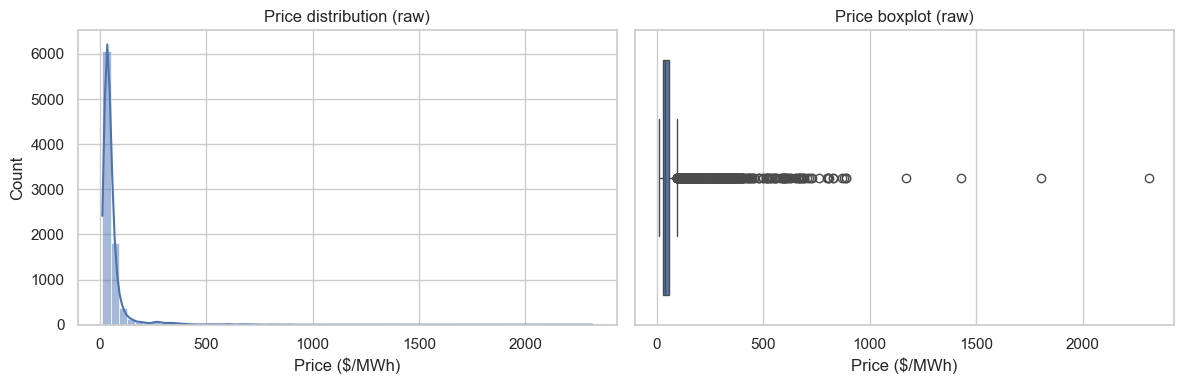

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(eda["price"], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Price distribution (raw)")
axes[0].set_xlabel("Price ($/MWh)")

sns.boxplot(x=eda["price"], ax=axes[1])
axes[1].set_title("Price boxplot (raw)")
axes[1].set_xlabel("Price ($/MWh)")

plt.tight_layout()
plt.show()

The price distribution is strongly right-skewed, with a long upper tail that reflects occasional price spikes. That makes RMSE an important companion metric to MAE in the modeling section.

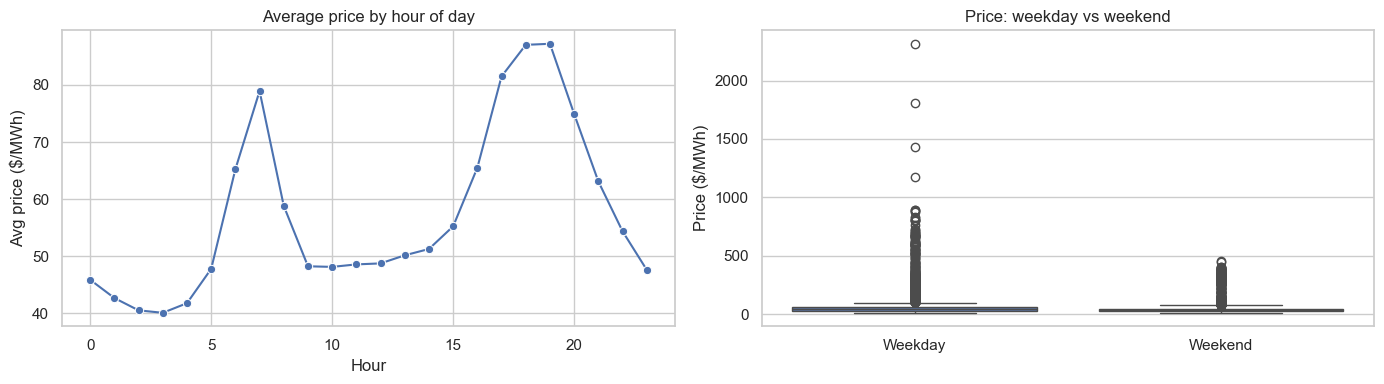

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hourly_profile = eda.groupby("hour")["price"].mean()
sns.lineplot(x=hourly_profile.index, y=hourly_profile.values, marker="o", ax=axes[0])
axes[0].set_title("Average price by hour of day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Avg price ($/MWh)")

weekday_vs_weekend = eda[["price", "is_weekend"]].copy()
weekday_vs_weekend["day_type"] = np.where(
    weekday_vs_weekend["is_weekend"] == 1,
    "Weekend",
    "Weekday",
)
sns.boxplot(data=weekday_vs_weekend, x="day_type", y="price", ax=axes[1])
axes[1].set_title("Price: weekday vs weekend")
axes[1].set_xlabel("")
axes[1].set_ylabel("Price ($/MWh)")

plt.tight_layout()
plt.show()

Prices follow a clear intraday pattern, and weekday hours are generally higher and more variable than weekend hours. This is exactly the kind of calendar structure the LSTM can capture with hour, day-of-week, and cyclical encodings.

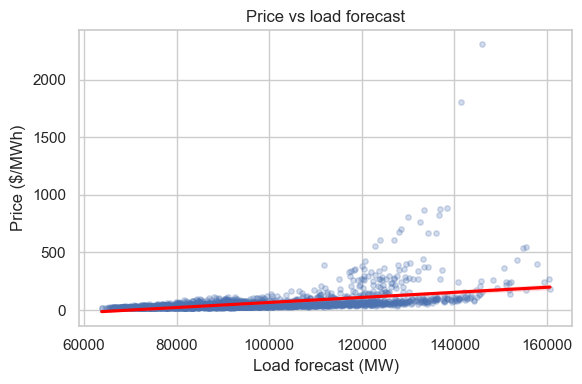

In [4]:
if "load_forecast_mw" in eda.columns:
    sample = eda.sample(min(len(eda), 3000), random_state=42)
    plt.figure(figsize=(6, 4))
    sns.regplot(
        data=sample,
        x="load_forecast_mw",
        y="price",
        scatter_kws={"alpha": 0.25, "s": 15},
        line_kws={"color": "red"},
    )
    plt.title("Price vs load forecast")
    plt.xlabel("Load forecast (MW)")
    plt.ylabel("Price ($/MWh)")
    plt.tight_layout()
    plt.show()
else:
    print("load_forecast_mw not found in initial_data.csv")

Load forecast has a visible positive relationship with price, which matches the supply-demand story behind day-ahead pricing. This is one of the strongest exogenous signals in the final feature set.

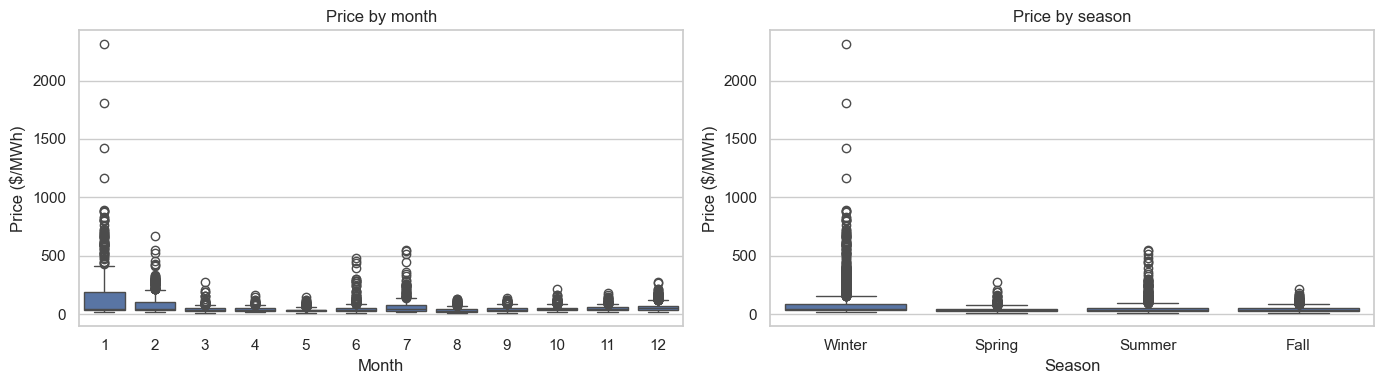

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=eda, x="month", y="price", ax=axes[0])
axes[0].set_title("Price by month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Price ($/MWh)")

season_map = {0: "Winter", 1: "Spring", 2: "Summer", 3: "Fall"}
season_plot = eda.copy()
season_plot["season_label"] = season_plot["season"].map(season_map)
sns.boxplot(
    data=season_plot,
    x="season_label",
    y="price",
    order=["Winter", "Spring", "Summer", "Fall"],
    ax=axes[1],
)
axes[1].set_title("Price by season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Price ($/MWh)")

plt.tight_layout()
plt.show()

Monthly and seasonal patterns are visible in the price distribution, with the winter months tending to sit higher and spread wider. That seasonal structure helps justify keeping month and season features in the model.

### Autocorrelation

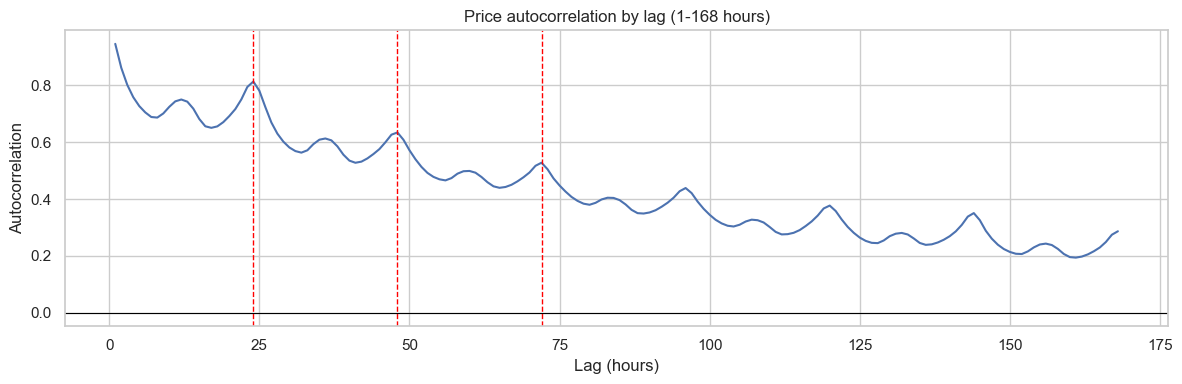

In [6]:
max_lag = 24 * 7
acf_vals = [eda["price"].autocorr(lag=i) for i in range(1, max_lag + 1)]
lags = np.arange(1, max_lag + 1)

plt.figure(figsize=(12, 4))
sns.lineplot(x=lags, y=acf_vals)
plt.axhline(0, color="black", linewidth=0.8)
for lag in (24, 48, 72):
    plt.axvline(lag, color="red", linestyle="--", linewidth=1)
plt.title("Price autocorrelation by lag (1-168 hours)")
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

The lag profile stays high across short horizons and shows clear daily structure around 24-hour multiples. That persistence is the main reason we include `price_lag_48` and `price_lag_168` in the final pipeline.

## Step 1: Persistence model

**Goal:** Compare naive persistence forecasts built from **48-hour** and **1-week (168-hour)** price lags on the same held-out test window. We report **MAE** and **RMSE** so that we can judge which horizon is more predictive and thus useful for our final LSTM model.

**Definitions:** For hourly data, persistence means $\hat{y}_t = y_{t-k}$ using the lag-$k$ column in features. One week at the same hour is $k=168$ (7×24).

## Setup

Imports and a fixed random seed.

In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

RNG_SEED = 42
np.random.seed(RNG_SEED)

## Load data and add long lags

Uses initial_data.csv. That file already has short lags; we add **`price_lag_48`** and **`price_lag_168`** from `price`, then drop rows with missing lags so metrics are only on valid rows.

In [21]:
DATA_PATH = "initial_data.csv"

df = pd.read_csv(DATA_PATH)
df["datetime_beginning_ept"] = pd.to_datetime(df["datetime_beginning_ept"])
df = df.sort_values("datetime_beginning_ept").set_index("datetime_beginning_ept")

df["price_lag_48"] = df["price"].shift(48)
df["price_lag_168"] = df["price"].shift(7 * 24)

lag_cols = ["price_lag_48", "price_lag_168"]
df = df.dropna(subset=lag_cols + ["price"])

print("Shape after lag dropna:", df.shape)
print("Index range:", df.index.min(), "→", df.index.max())
df[lag_cols].head()

Shape after lag dropna: (8568, 29)
Index range: 2025-04-15 00:00:00 → 2026-04-07 00:00:00


,price_lag_48,price_lag_168
datetime_beginning_ept,,
2025-04-15 00:00:00,61.521585,48.900998
2025-04-15 01:00:00,44.033375,46.402496
2025-04-15 02:00:00,35.028002,45.297246
2025-04-15 03:00:00,34.611806,46.532548
2025-04-15 04:00:00,35.527041,48.516346


## Time-aware train / validation / test split

Same logic as the baseline notebook: **no shuffling**, chronological **70% / 15% / 15%** so the test period is strictly later in time.

In [22]:
def time_series_split(
    frame: pd.DataFrame,
    target_col: str = "price",
    train_frac: float = 0.70,
    val_frac: float = 0.15,
):
    # Split time-ordered frame into train / val / test (no shuffle).
    n = len(frame)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))

    feature_cols = [c for c in frame.columns if c != target_col]

    train_df = frame.iloc[:train_end]
    val_df = frame.iloc[train_end:val_end]
    test_df = frame.iloc[val_end:]

    X_train = train_df[feature_cols].copy()
    y_train = train_df[target_col].copy()
    X_val = val_df[feature_cols].copy()
    y_val = val_df[target_col].copy()
    X_test = test_df[feature_cols].copy()
    y_test = test_df[target_col].copy()

    return X_train, y_train, X_val, y_val, X_test, y_test


X_train, y_train, X_val, y_val, X_test, y_test = time_series_split(df)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
print("Test window:", X_test.index.min(), "→", X_test.index.max())

Train: (5997, 28) | Val: (1285, 28) | Test: (1286, 28)
Test window: 2026-02-12 10:00:00 → 2026-04-07 00:00:00


## Persistence models and metrics

**Persistence:** $\hat{y}_t$ equals the price observed $k$ hours earlier (`price_lag_k`). **MAE** is typical error; **RMSE** weights spikes more, matching our dual-metric rationale from MS3.

In [23]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse


rows = []
for lag_name, col in [
    ("Persistence (48h)", "price_lag_48"),
    ("Persistence (1 week)", "price_lag_168"),
]:
    y_pred = X_test[col].to_numpy()
    mae, rmse = regression_metrics(y_test, y_pred)
    rows.append({"Model": lag_name, "Lag hours": int(col.rsplit("_", 1)[-1]), "MAE": mae, "RMSE": rmse})

results = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
results

,Model,Lag hours,MAE,RMSE
0,Persistence (48h),48,14.175086,22.875045
1,Persistence (1 week),168,23.161591,48.136436


We see that the persistence model for 48 hour lag does much better in both MAE and RMSE compared to the 1 week persistence model. Based on this, we will use the 48 hour lag price as a feature in our final LSTM model.

# Step 2: LSTM Modeling Pipeline (Day-Ahead, Hourly Output)

Everything below this header is the LSTM section. It rebuilds **leakage-safe** features under the day-ahead market rule, then trains, tunes, and evaluates an **hourly** LSTM that predicts one delivery-hour price at a time.

**Why hourly instead of "predict all 24 prices at once"?** The previous version of this notebook predicted the full 24-hour delivery-day curve in one forward pass. That made the LSTM structurally different from the persistence and Random Forest baselines (both of which are hourly), and the comparison was not apples-to-apples. We now train the LSTM in the same hourly granularity as those baselines:

- `X.shape = (num_hourly_samples, lookback_window, num_features)`
- `y.shape = (num_hourly_samples,)`

**Market / leakage rule.** PJM publishes the 24 day-ahead hourly prices for delivery day `D` before `D` actually starts. We assume bids/forecasts must be locked in by **`D-1` 10:30 AM Eastern**. So when predicting any hour on `D`, **no feature row may use any realized/real-time information dated after `D-1` 10:30 AM ET**.

How each feature handles this:

- **Forecasted variables** (`load_forecast_mw`, `forecast_gen_outage_mw_rto`) – assumed to be the day-ahead forecasts available before the cutoff, used directly for the target hour. (No `evaluated_at_ept`-style timestamp column is present in `initial_data.csv`, so this is documented as an assumption.)
- **Realized generation by fuel** (`coal_mw`, `gas_mw`, `nuclear_mw`, `wind_mw`, `solar_mw`, `hydro_mw`, `oil_mw`, `storage_mw`, `multiple_fuels_mw`, `other_renewables_mw`, `renewable_mw`) – lagged by 48 hours; the un-lagged columns are dropped.
- **Price persistence** – `price_lag_48` (primary, motivated by Step 1) and `price_lag_168` (optional weekly seasonality). `price_lag_1`, `price_lag_24`, and the unsafe `price_roll_24` are dropped.
- **Price level context** – a leakage-safe `price_roll_24_safe` that is constant across the 24 hours of each delivery day and uses only prices observed up to `D-1` 10:00 AM.
- **Calendar features** – known in advance, always safe.

The previous run of the daily-output LSTM (test RMSE ≈ 21.0) is preserved in `lstm_outputs/` from the prior commit; the new hourly LSTM below is the **main final model**.

## 2.1 Setup: imports, seeds, output directory

PyTorch is used for the LSTM. Output artifacts (trained model, metrics, importance, plots) go in `lstm_outputs/`.

In [24]:
import os
import json
import random
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

LSTM_SEED = 42
np.random.seed(LSTM_SEED)
random.seed(LSTM_SEED)
torch.manual_seed(LSTM_SEED)

# Pick the best available device. MPS is the Apple Silicon GPU back-end and
# can give a meaningful speedup over CPU for the hourly LSTM (which has many
# more samples than the previous daily LSTM did).
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

OUTPUT_DIR = "lstm_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Day-ahead market cutoff: D-1 at 10:30 AM Eastern.
CUTOFF_HOUR = 10
CUTOFF_MINUTE = 30

print("PyTorch:", torch.__version__, "| Device:", DEVICE)
print("Output dir:", OUTPUT_DIR)

PyTorch: 2.11.0 | Device: mps
Output dir: lstm_outputs


## 2.2 Load data and define cutoff helper

`load_data` reloads the cleaned dataset and re-indexes by `datetime_beginning_ept`. `create_cutoff_time(D)` returns the cutoff timestamp `D-1 10:30 ET` for a delivery date `D`; this is used both for the leakage-safe rolling feature and for the assertion checks below.

In [25]:
def load_data(path: str = "initial_data.csv") -> pd.DataFrame:
    df = pd.read_csv(path)
    df["datetime_beginning_ept"] = pd.to_datetime(df["datetime_beginning_ept"])
    df = df.sort_values("datetime_beginning_ept").set_index("datetime_beginning_ept")
    df.index.name = "datetime_ept"
    return df


def create_cutoff_time(delivery_date) -> pd.Timestamp:
    """Cutoff = D-1 at 10:30 AM ET for a given delivery date D."""
    d = pd.Timestamp(delivery_date).normalize()
    return d - pd.Timedelta(days=1) + pd.Timedelta(hours=CUTOFF_HOUR, minutes=CUTOFF_MINUTE)


raw_df = load_data()
print("Raw shape:", raw_df.shape)
print("Date range:", raw_df.index.min(), "→", raw_df.index.max())
print("Example cutoff for delivery 2026-01-15:", create_cutoff_time("2026-01-15"))

Raw shape: (8736, 27)
Date range: 2025-04-08 00:00:00 → 2026-04-07 00:00:00
Example cutoff for delivery 2026-01-15: 2026-01-14 10:30:00


## 2.3 Safe feature engineering

Three small composable helpers:

1. `create_safe_lag_features` builds `price_lag_48` (primary, per Step 1), `price_lag_168` (optional weekly), and `*_lag_48` (and optionally `*_lag_168`) for every realized fuel/generation series.
2. `drop_unsafe_columns` removes the unsafe shortcut columns from `initial_data.csv` (`price_lag_1`, `price_lag_24`, `price_roll_24`) **and** the un-lagged generation columns so no leakage occurs.
3. `create_price_roll_24_safe` attaches one constant `price_roll_24_safe` value per delivery day, computed only from the most recent 24 hourly prices ending at `D-1 10:00 AM` (fully observed before the `D-1 10:30` cutoff).

We then assert that none of the unsafe column names is present in the resulting frame.

In [26]:
# Realized generation columns we must lag (never use same-hour values).
GENERATION_VARS = [
    "coal_mw", "gas_mw", "nuclear_mw", "wind_mw", "solar_mw",
    "hydro_mw", "oil_mw", "storage_mw", "multiple_fuels_mw",
    "other_renewables_mw", "renewable_mw",
]

# Calendar features – known well in advance, always safe.
CALENDAR_FEATURES = [
    "hour", "day_of_week", "month", "is_weekend", "is_holiday",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
]

# Forecasted variables – assumed published before the D-1 10:30 cutoff.
FORECAST_FEATURES = ["load_forecast_mw", "forecast_gen_outage_mw_rto"]

# Columns from initial_data.csv that would leak target-day info if kept as-is.
UNSAFE_COLS = ["price_lag_1", "price_lag_24", "price_roll_24"]


def create_safe_lag_features(df: pd.DataFrame, include_lag_168_gen: bool = True) -> pd.DataFrame:
    """Build leakage-safe price and generation lag columns.

    - price_lag_48 (primary, per Step 1) and price_lag_168 (optional weekly).
    - <gen>_lag_48 for every realized fuel/generation column.
    - Optionally also <gen>_lag_168 for feature-selection comparison.
    """
    df = df.copy()
    df["price_lag_48"] = df["price"].shift(48)
    df["price_lag_168"] = df["price"].shift(168)
    for col in GENERATION_VARS:
        if col in df.columns:
            df[f"{col}_lag_48"] = df[col].shift(48)
            if include_lag_168_gen:
                df[f"{col}_lag_168"] = df[col].shift(168)
    return df


def drop_unsafe_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Drop every column that would leak target-day info if used as-is.

    This includes the unsafe shortcut columns from initial_data.csv
    (price_lag_1, price_lag_24, price_roll_24) and every un-lagged realized
    generation column. After this call no leakage-prone column survives.
    """
    drop_cols = [c for c in UNSAFE_COLS + GENERATION_VARS if c in df.columns]
    return df.drop(columns=drop_cols)


def create_price_roll_24_safe(df: pd.DataFrame) -> pd.DataFrame:
    """Attach a per-delivery-day rolling-24h price mean usable before the cutoff.

    For delivery day D, the window is the 24 hourly prices in
    [D-2 11:00, D-1 10:00] (inclusive) – the most recent complete 24h block
    fully observed before the D-1 10:30 cutoff. The same scalar value is
    written to all 24 rows of delivery day D, so every target hour of D
    sees the *same* price_roll_24_safe value.
    """
    df = df.copy()
    if "price" not in df.columns:
        raise ValueError("price column required to compute rolling feature")

    delivery_dates = pd.Series(df.index.normalize().unique()).sort_values()

    roll_map: dict[pd.Timestamp, float] = {}
    for d in delivery_dates:
        window_end = d - pd.Timedelta(days=1) + pd.Timedelta(hours=10)  # D-1 10:00
        window_start = window_end - pd.Timedelta(hours=23)              # D-2 11:00
        mask = (df.index >= window_start) & (df.index <= window_end)
        window_prices = df.loc[mask, "price"]
        roll_map[d] = float(window_prices.mean()) if len(window_prices) == 24 else np.nan

    delivery_key = df.index.normalize()
    df["price_roll_24_safe"] = pd.Series(delivery_key, index=df.index).map(roll_map).values
    return df


df_safe = create_safe_lag_features(raw_df)
df_safe = create_price_roll_24_safe(df_safe)
df_safe = drop_unsafe_columns(df_safe)

# Drop rows where any required safe feature is still NaN (warm-up window).
required_cols = [
    "price", "price_lag_48", "price_lag_168", "price_roll_24_safe",
] + [f"{v}_lag_48" for v in GENERATION_VARS if v in raw_df.columns]
df_safe = df_safe.dropna(subset=required_cols)

# --- Hard assertions: no unsafe column survives. ---
for c in UNSAFE_COLS:
    assert c not in df_safe.columns, f"unsafe column {c!r} leaked through into df_safe"
for c in GENERATION_VARS:
    assert c not in df_safe.columns, f"unlagged generation column {c!r} leaked through into df_safe"

print("Safe feature frame shape:", df_safe.shape)
print("Date range:", df_safe.index.min(), "→", df_safe.index.max())
print("Sample columns:", [c for c in df_safe.columns if "lag_48" in c or "roll" in c][:8], "...")
df_safe.head(3)

Safe feature frame shape: (8544, 38)
Date range: 2025-04-15 00:00:00 → 2026-04-07 00:00:00
Sample columns: ['price_lag_48', 'coal_mw_lag_48', 'gas_mw_lag_48', 'nuclear_mw_lag_48', 'wind_mw_lag_48', 'solar_mw_lag_48', 'hydro_mw_lag_48', 'oil_mw_lag_48'] ...


,price,load_forecast_mw,forecast_gen_outage_mw_rto,hour,day_of_week,month,is_weekend,season,is_holiday,hour_sin,...,oil_mw_lag_168,storage_mw_lag_48,storage_mw_lag_168,multiple_fuels_mw_lag_48,multiple_fuels_mw_lag_168,other_renewables_mw_lag_48,other_renewables_mw_lag_168,renewable_mw_lag_48,renewable_mw_lag_168,price_roll_24_safe
datetime_ept,,,,,,,,,,,,,,,,,,,,,
2025-04-15 00:00:00,29.678878,72428,55360.0,0,1,4,0,1,0,0.000000,...,288.0,0.0,0.0,692.0,1142.0,507.0,569.0,4387.0,4493.0,43.764458
2025-04-15 01:00:00,29.835361,70306,55360.0,1,1,4,0,1,0,0.258819,...,291.0,0.0,0.0,704.0,1082.0,517.0,562.0,3678.0,4353.0,43.764458
2025-04-15 02:00:00,28.199786,69106,55360.0,2,1,4,0,1,0,0.500000,...,268.0,0.0,0.0,733.0,948.0,522.0,530.0,3725.0,4199.0,43.764458


## 2.4 Leakage assertion checks

A small unit-style audit. For randomly sampled delivery days `D` we verify:

1. `price_roll_24_safe` is constant across all 24 rows of day `D`.
2. Every `*_lag_48` value at any hour `t` of day `D` references a timestamp `t-48h` that is strictly earlier than the cutoff `D-1 10:30`.
3. `price_roll_24_safe` for day `D` was computed only from prices observed at or before `D-1 10:00`.

Any violation raises immediately so we can't accidentally proceed with leaky features.

In [27]:
def verify_no_leakage(df: pd.DataFrame, raw_price_series: pd.Series, sample_n_days: int = 50) -> None:
    """Assert that no feature for delivery day D references info after D-1 10:30."""
    delivery_dates = pd.Series(df.index.normalize().unique()).sort_values()
    sample = delivery_dates.sample(min(sample_n_days, len(delivery_dates)), random_state=LSTM_SEED)

    for d in sample:
        cutoff = create_cutoff_time(d)
        day_rows = df[df.index.normalize() == d]
        if len(day_rows) == 0:
            continue

        # (1) price_roll_24_safe constant across the day.
        roll_vals = day_rows["price_roll_24_safe"].dropna().unique()
        assert len(roll_vals) == 1, f"{d}: price_roll_24_safe not constant within delivery day"

        # (2) every lag_48 reference is strictly before cutoff.
        for t in day_rows.index:
            ref_t = t - pd.Timedelta(hours=48)
            assert ref_t < cutoff, f"{d}: lag_48 reference {ref_t} >= cutoff {cutoff}"

        # (3) the rolling window source prices are observed before cutoff.
        window_end = d - pd.Timedelta(days=1) + pd.Timedelta(hours=10)
        window_start = window_end - pd.Timedelta(hours=23)
        assert window_end < cutoff, f"{d}: rolling window end {window_end} not before cutoff {cutoff}"
        # Recompute and compare to the stored value.
        win = raw_price_series.loc[(raw_price_series.index >= window_start) &
                                   (raw_price_series.index <= window_end)]
        if len(win) == 24:
            assert np.isclose(roll_vals[0], win.mean()), f"{d}: stored roll != recomputed mean"


verify_no_leakage(df_safe, raw_df["price"], sample_n_days=50)
print("Leakage assertions passed for 50 sampled delivery days.")

Leakage assertions passed for 50 sampled delivery days.


## 2.5 Feature groups and chronological split

`build_feature_groups` creates the four nested feature sets we will compare in §2.9:

- `price_only` – just price-history features.
- `price_calendar` – adds calendar / cyclical time features.
- `price_calendar_forecast` – adds the day-ahead forecasts (load / outage).
- `all_features` – also adds the lagged generation-by-fuel features.

`chronological_day_split` then splits **by delivery day** (not by row) into 70 / 15 / 15 train / val / test. Splitting by day means each sample (one day's 24-hour sequence + 24-hour target) lives entirely inside one split.

In [28]:
def build_feature_groups(df: pd.DataFrame) -> dict[str, list[str]]:
    """Build nested feature lists for the feature-group comparison.

    All four groups are built from columns that have already been screened by
    `drop_unsafe_columns`, so by construction they only contain leakage-safe
    features. We re-assert that below.
    """
    price_features = [c for c in ["price_lag_48", "price_lag_168", "price_roll_24_safe"] if c in df.columns]
    calendar_features = [c for c in CALENDAR_FEATURES if c in df.columns]
    forecast_features = [c for c in FORECAST_FEATURES if c in df.columns]
    gen_lag_features = [c for c in df.columns
                        if c.endswith("_lag_48") and c != "price_lag_48"]
    return {
        "price_only": price_features,
        "price_calendar": price_features + calendar_features,
        "price_calendar_forecast": price_features + calendar_features + forecast_features,
        "all_features": price_features + calendar_features + forecast_features + gen_lag_features,
    }


def assert_group_is_leakage_safe(name: str, features: list[str]) -> None:
    """Per-group sanity check: no feature is on the known-unsafe list."""
    forbidden = set(UNSAFE_COLS) | set(GENERATION_VARS)
    bad = [f for f in features if f in forbidden]
    assert not bad, f"feature group {name!r} contains unsafe columns: {bad}"


def chronological_split(df: pd.DataFrame, train_frac: float = 0.70, val_frac: float = 0.15
                        ) -> tuple[list, list, list]:
    """Split delivery days chronologically – no shuffling, no day spans two splits.

    We split by **delivery day** (not by row) so that all 24 hours of a given
    day live entirely inside one split. The hourly LSTM later treats each
    hour inside these days as one training/eval sample.
    """
    delivery_dates = pd.Series(df.index.normalize().unique()).sort_values().reset_index(drop=True)
    n = len(delivery_dates)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))
    return (
        list(delivery_dates.iloc[:train_end]),
        list(delivery_dates.iloc[train_end:val_end]),
        list(delivery_dates.iloc[val_end:]),
    )


# Backwards-compatible alias – the previous (daily) section used this name.
chronological_day_split = chronological_split


feature_groups = build_feature_groups(df_safe)
for name, feats in feature_groups.items():
    assert_group_is_leakage_safe(name, feats)
    print(f"  {name:25s}: {len(feats):2d} features  -> {feats[:4]}{' ...' if len(feats) > 4 else ''}")

train_dates, val_dates, test_dates = chronological_split(df_safe)
print()
print(f"Train: {len(train_dates):3d} days  ({train_dates[0].date()} → {train_dates[-1].date()})")
print(f"Val  : {len(val_dates):3d} days  ({val_dates[0].date()} → {val_dates[-1].date()})")
print(f"Test : {len(test_dates):3d} days  ({test_dates[0].date()} → {test_dates[-1].date()})")

  price_only               :  3 features  -> ['price_lag_48', 'price_lag_168', 'price_roll_24_safe']
  price_calendar           : 12 features  -> ['price_lag_48', 'price_lag_168', 'price_roll_24_safe', 'hour'] ...
  price_calendar_forecast  : 14 features  -> ['price_lag_48', 'price_lag_168', 'price_roll_24_safe', 'hour'] ...
  all_features             : 25 features  -> ['price_lag_48', 'price_lag_168', 'price_roll_24_safe', 'hour'] ...

Train: 249 days  (2025-04-15 → 2025-12-19)
Val  :  54 days  (2025-12-20 → 2026-02-11)
Test :  54 days  (2026-02-12 → 2026-04-07)


## 2.6 Hourly LSTM sequence construction

For each target hour `t` whose delivery day is in the chosen split:

- `X[t]` is the `(lookback, num_features)` window of leakage-safe feature rows `[t - lookback + 1, ..., t]` (inclusive of `t`).
- `y[t]` is the realized scalar price at hour `t`.

The window can include row `t` itself because every feature value at row `t` is leakage-safe by construction:

- `price_lag_48` and `*_lag_48` reference `t - 48h`, which is well before the `D-1 10:30` cutoff for any `t ∈ D`.
- `price_lag_168` is even further back, namely one week.
- `price_roll_24_safe` is the per-day constant computed only from prices observed up to `D-1 10:00`.
- Calendar features are known in advance.
- `load_forecast_mw`, `forecast_gen_outage_mw_rto` are assumed to be the day-ahead forecasts published before the cutoff (documented assumption in §2.3).
- The target `price` itself is **not** included in the feature list, so the LSTM never sees the answer in its own input.

Resulting tensor shapes:

- `X.shape = (num_hourly_samples, lookback_window, num_features)`
- `y.shape = (num_hourly_samples,)`

We compare `lookback ∈ {48, 168}` in §2.8/§2.9. Scaling: `StandardScaler` for features and a separate one for the target, both fit on training rows only; predictions are inverse-transformed before any metric, meaning we un-standardize them back to the scale they were originally inputted as.

In [29]:
def scale_features(df: pd.DataFrame, features: list[str], target_col: str,
                   train_dates) -> tuple[pd.DataFrame, StandardScaler, StandardScaler]:
    """Fit StandardScalers for features and target on TRAINING rows only,
    then return a copy of `df` with both scaled in place."""
    train_set = {pd.Timestamp(d).normalize() for d in train_dates}
    train_rows = df[df.index.normalize().isin(train_set)]

    feat_scaler = StandardScaler().fit(train_rows[features].values)
    target_scaler = StandardScaler().fit(train_rows[[target_col]].values)

    df_scaled = df.copy()
    df_scaled[features] = feat_scaler.transform(df[features].values)
    df_scaled[target_col] = target_scaler.transform(df[[target_col]].values)
    return df_scaled, feat_scaler, target_scaler


def create_hourly_lstm_sequences(df: pd.DataFrame, features: list[str], lookback: int,
                                 target_dates) -> tuple[np.ndarray, np.ndarray, list]:
    """Build (X, y, timestamps) for the **hourly** LSTM.

    For each hour `t` whose delivery day is in `target_dates`:
        X[t] = features at rows [t - lookback + 1, ..., t]   shape (lookback, n_feat)
        y[t] = price at t                                    scalar

    Returns:
        X: (num_samples, lookback, num_features)
        y: (num_samples,)
        timestamps: list of pd.Timestamp, one per sample (the target hour)

    The lookback may extend backwards across the train/val/test boundary; that
    is allowed because the input window only contains *features* (no realized
    target prices for hour t), and every feature is leakage-safe under the
    D-1 10:30 cutoff for the row it sits on.
    """
    target_set = {pd.Timestamp(d).normalize() for d in target_dates}
    feat_array = df[features].to_numpy(dtype=np.float32)
    price_array = df["price"].to_numpy(dtype=np.float32)
    times = df.index
    n = len(df)

    Xs: list[np.ndarray] = []
    ys: list[float] = []
    ts: list[pd.Timestamp] = []

    for i in range(lookback - 1, n):
        if times[i].normalize() not in target_set:
            continue
        if np.isnan(price_array[i]):
            continue
        window = feat_array[i - lookback + 1: i + 1]
        if np.isnan(window).any():
            continue
        Xs.append(window)
        ys.append(price_array[i])
        ts.append(times[i])

    if not Xs:
        return (np.empty((0, lookback, len(features)), dtype=np.float32),
                np.empty((0,), dtype=np.float32), [])
    return np.stack(Xs), np.array(ys, dtype=np.float32), ts


def prepare_hourly_lstm_data(df: pd.DataFrame, features: list[str], lookback: int,
                             train_dates, val_dates, test_dates):
    """End-to-end: scale once on train rows, then build hourly sequences for each split."""
    df_scaled, feat_scaler, target_scaler = scale_features(df, features, "price", train_dates)
    train = create_hourly_lstm_sequences(df_scaled, features, lookback, train_dates)
    val = create_hourly_lstm_sequences(df_scaled, features, lookback, val_dates)
    test = create_hourly_lstm_sequences(df_scaled, features, lookback, test_dates)
    return train, val, test, feat_scaler, target_scaler


# Quick smoke check: build hourly sequences for one feature group / lookback.
_demo_feats = feature_groups["price_calendar"]
(_Xtr, _ytr, _ttr), (_Xv, _yv, _tv), (_Xte, _yte, _tte), _, _ = prepare_hourly_lstm_data(
    df_safe, _demo_feats, lookback=48,
    train_dates=train_dates, val_dates=val_dates, test_dates=test_dates,
)
print(f"price_calendar / lookback=48 → "
      f"train X={_Xtr.shape} y={_ytr.shape} | val X={_Xv.shape} | test X={_Xte.shape}")
assert _ytr.ndim == 1, "Hourly LSTM target must be 1-D (one scalar per hourly sample)"
assert _Xtr.shape[1] == 48 and _Xtr.shape[2] == len(_demo_feats), "Unexpected X shape for hourly LSTM"

price_calendar / lookback=48 → train X=(5929, 48, 12) y=(5929,) | val X=(1296, 48, 12) | test X=(1272, 48, 12)


## 2.7 Hourly LSTM model, training loop, and evaluation

Compact PyTorch LSTM with optional stacked layers and dropout. The output is a **single scalar per sample** (one delivery-hour price). Training uses MSE in scaled space, Adam, mini-batches, and early stopping on validation MSE. `evaluate_predictions` always inverse-transforms predictions before computing MAE / RMSE in original ($/MWh) units. We assert the output shape is `(batch_size,)` so the structural change to hourly is enforced at runtime.

In [30]:
class HourlyLSTMRegressor(nn.Module):
    """LSTM that maps a (lookback, num_features) window to ONE scalar price."""

    def __init__(self, num_features: int, hidden_size: int = 64,
                 num_layers: int = 1, dropout: float = 0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        # squeeze last dim → shape (batch_size,)
        return self.head(self.dropout(last)).squeeze(-1)


def define_lstm_model(num_features: int, hidden_size: int = 64,
                      num_layers: int = 1, dropout: float = 0.1) -> nn.Module:
    """Factory used by train_lstm and the smoke-test cell below."""
    return HourlyLSTMRegressor(num_features, hidden_size, num_layers, dropout)


def train_lstm(X_train, y_train, X_val, y_val,
               hidden_size: int = 64, num_layers: int = 1, dropout: float = 0.1,
               learning_rate: float = 1e-3, batch_size: int = 64,
               epochs: int = 50, patience: int = 8,
               verbose: bool = False, seed: int = LSTM_SEED):
    """Train an hourly LSTM with early stopping on validation MSE."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    num_features = X_train.shape[2]

    X_tr_t = torch.tensor(X_train, dtype=torch.float32, device=DEVICE)
    y_tr_t = torch.tensor(y_train, dtype=torch.float32, device=DEVICE)
    X_va_t = torch.tensor(X_val, dtype=torch.float32, device=DEVICE)
    y_va_t = torch.tensor(y_val, dtype=torch.float32, device=DEVICE)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)

    model = define_lstm_model(num_features, hidden_size, num_layers, dropout).to(DEVICE)
    optim = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    bad_epochs = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        running = 0.0
        for xb, yb in loader:
            optim.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optim.step()
            running += loss.item() * xb.size(0)
        train_loss = running / len(X_tr_t)

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_va_t), y_va_t).item()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

        if verbose and epoch % 5 == 0:
            print(f"  epoch {epoch:3d}: train_mse={train_loss:.4f} val_mse={val_loss:.4f}")

    model.load_state_dict(best_state)
    return model, train_losses, val_losses


def evaluate_predictions(model, X, y_scaled, target_scaler):
    """Forward pass + inverse-scale + MAE / RMSE in original ($/MWh) units.

    Works for hourly LSTM where y_scaled has shape (n_samples,).
    """
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        pred_scaled = model(X_t).cpu().numpy()
    pred = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    y_orig = target_scaler.inverse_transform(np.asarray(y_scaled).reshape(-1, 1)).flatten()
    mae = mean_absolute_error(y_orig, pred)
    rmse = float(np.sqrt(mean_squared_error(y_orig, pred)))
    return mae, rmse, pred, y_orig


# Backwards-compatible alias for any older code paths that still call evaluate_model.
evaluate_model = evaluate_predictions


# --- Output-shape sanity check: one scalar per hourly sample. ---
_dummy_model = define_lstm_model(num_features=_Xtr.shape[2]).to(DEVICE)
_dummy_pred = _dummy_model(torch.tensor(_Xtr[:5], dtype=torch.float32, device=DEVICE))
assert _dummy_pred.shape == (5,), \
    f"Hourly LSTM must output one scalar per sample; got shape {_dummy_pred.shape}"
print(f"Output-shape check passed: {tuple(_dummy_pred.shape)}  (one scalar per hourly sample)")

Output-shape check passed: (5,)  (one scalar per hourly sample)


## 2.8 Default-hyperparameter baseline on `all_features`

§2.8 fixes the feature set to `all_features` and trains the hourly LSTM at **default hyperparameters** for both `lookback ∈ {48, 168}`. This produces a small baseline table that the §2.9 hyperparameter search has to beat. Defaults are kept light (epochs=30, patience=6, hidden=64, layers=1, dropout=0.2, lr=1e-3, batch=64) so the baseline finishes in a few minutes.

In [53]:
DEFAULT_HP = dict(
    hidden_size=64,
    num_layers=1,
    dropout=0.2,
    learning_rate=1e-3,
    batch_size=64,
    epochs=30,
    patience=6,
)


def run_feature_group_experiments(df, feature_groups, train_dates, val_dates, test_dates,
                                  lookbacks=(48, 168), default_hp=None):
    """For each (group, lookback) train an hourly LSTM at default HP and report metrics."""
    if default_hp is None:
        default_hp = DEFAULT_HP

    rows = []
    for group_name, features in feature_groups.items():
        assert_group_is_leakage_safe(group_name, features)
        for lookback in lookbacks:
            (X_tr, y_tr, _), (X_val, y_val, _), (X_te, y_te, _), _, target_scaler = \
                prepare_hourly_lstm_data(df, features, lookback, train_dates, val_dates, test_dates)
            if len(X_tr) == 0 or len(X_val) == 0 or len(X_te) == 0:
                print(f"  skipping {group_name}/lookback={lookback}: empty sequences")
                continue

            model, _, _ = train_lstm(X_tr, y_tr, X_val, y_val, **default_hp)
            val_mae, val_rmse, _, _ = evaluate_predictions(model, X_val, y_val, target_scaler)
            test_mae, test_rmse, _, _ = evaluate_predictions(model, X_te, y_te, target_scaler)

            rows.append({
                "feature_group": group_name,
                "lookback": lookback,
                "n_features": len(features),
                "hidden_size": default_hp["hidden_size"],
                "num_layers": default_hp["num_layers"],
                "dropout": default_hp["dropout"],
                "learning_rate": default_hp["learning_rate"],
                "val_MAE": val_mae,
                "val_RMSE": val_rmse,
                "test_MAE": test_mae,
                "test_RMSE": test_rmse,
            })
            print(f"  {group_name:25s} L={lookback:3d}  "
                  f"val MAE={val_mae:6.3f} RMSE={val_rmse:6.3f}  |  "
                  f"test MAE={test_mae:6.3f} RMSE={test_rmse:6.3f}")

    return pd.DataFrame(rows).sort_values("val_RMSE").reset_index(drop=True)


# We are no longer doing feature selection — fix the feature set to `all_features`
# and use this cell purely as a default-HP baseline at the two lookbacks.
best_group_name = "all_features"
best_features   = feature_groups[best_group_name]
final_features  = best_features  # set here so downstream cells (§2.10, §2.13, ...) see it

print(f"Feature set fixed to '{best_group_name}' "
      f"({len(best_features)} leakage-safe features).\n")
print("Training default-HP hourly LSTM at lookback ∈ {48, 168} as a baseline:\n")

group_results_df = run_feature_group_experiments(
    df_safe,
    {best_group_name: best_features},   # single-group dict ⇒ 2 rows (one per lookback)
    train_dates, val_dates, test_dates,
)
group_results_df

Feature set fixed to 'all_features' (25 leakage-safe features).

Training default-HP hourly LSTM at lookback ∈ {48, 168} as a baseline:

  all_features              L= 48  val MAE=78.325 RMSE=179.267  |  test MAE= 7.923 RMSE=13.657
  all_features              L=168  val MAE=79.848 RMSE=180.912  |  test MAE= 9.297 RMSE=15.413


,feature_group,lookback,n_features,hidden_size,num_layers,dropout,learning_rate,val_MAE,val_RMSE,test_MAE,test_RMSE
0,all_features,48,25,64,1,0.2,0.001,78.325356,179.267139,7.922884,13.656612
1,all_features,168,25,64,1,0.2,0.001,79.848305,180.912401,9.297009,15.413297


A note on val MAE and RMSE vs. test MAE and RMSE: Since the validation/test split was done chronologically, the validation split was in a winter and test was not. Since winter prices for electricity are typically much higher than in spring months, this explains the large difference in val vs test MAE and RMSE.

## 2.9 Lightweight hyperparameter search on `all_features`

This is the **only** model-selection step in the pipeline. The feature set is fixed (the `all_features` group from §2.8); we are tuning `lookback × hidden_size × num_layers × dropout × learning_rate × batch_size` on top of that.

The full grid in the spec is `2 × 3 × 2 × 4 × 3 × 2 = 288` combinations, which is too expensive to run locally on the hourly LSTM (each trial trains on ~6,000 hourly samples for up to ~50 epochs). We sample `N_TRIALS` random combinations from the grid and pick the best by validation RMSE. If you need it faster, lower `N_TRIALS` or `epochs`.

In [54]:
HP_GRID = {
    "lookback":      [48, 168],
    "hidden_size":   [32, 64, 128],
    "num_layers":    [1, 2],
    "dropout":       [0.0, 0.1, 0.2, 0.3],
    "learning_rate": [1e-3, 5e-4, 1e-4],
    "batch_size":    [32, 64],
}
N_TRIALS = 8  # random search keeps wall-time reasonable on a laptop


def run_hyperparameter_search(df, features, train_dates, val_dates, test_dates,
                              hp_grid=None, n_trials=N_TRIALS, seed=LSTM_SEED,
                              epochs=40, patience=8):
    """Random search over `hp_grid`, ranked by validation RMSE."""
    if hp_grid is None:
        hp_grid = HP_GRID
    all_combos = list(itertools.product(*hp_grid.values()))
    random.seed(seed)
    sampled = random.sample(all_combos, min(n_trials, len(all_combos)))

    rows = []
    for combo in sampled:
        hp = dict(zip(hp_grid.keys(), combo))
        lookback = hp.pop("lookback")

        (X_tr, y_tr, _), (X_val, y_val, _), (X_te, y_te, _), _, target_scaler = \
            prepare_hourly_lstm_data(df, features, lookback, train_dates, val_dates, test_dates)
        model, _, _ = train_lstm(X_tr, y_tr, X_val, y_val,
                                 epochs=epochs, patience=patience, **hp)
        val_mae, val_rmse, _, _ = evaluate_predictions(model, X_val, y_val, target_scaler)
        test_mae, test_rmse, _, _ = evaluate_predictions(model, X_te, y_te, target_scaler)

        rows.append({
            "lookback": lookback, **hp,
            "val_MAE": val_mae, "val_RMSE": val_rmse,
            "test_MAE": test_mae, "test_RMSE": test_rmse,
        })
        print(f"  L={lookback:3d}  h={hp['hidden_size']:3d}  layers={hp['num_layers']}  "
              f"drop={hp['dropout']:.1f}  lr={hp['learning_rate']:.0e}  bs={hp['batch_size']:2d}  "
              f"->  val_RMSE={val_rmse:6.3f}")

    return pd.DataFrame(rows).sort_values("val_RMSE").reset_index(drop=True)


# `best_group_name` and `best_features` were fixed to "all_features" in §2.8.
# §2.9 only searches over hyperparameters; lookback is one of those hyperparameters.
print(f"Tuning hyperparameters on the '{best_group_name}' feature set "
      f"({len(best_features)} features) ...\n")
print(f"Default-HP baseline to beat (from §2.8):")
print(group_results_df[["lookback", "val_RMSE", "test_MAE", "test_RMSE"]].to_string(index=False))
print()

hp_results_df = run_hyperparameter_search(df_safe, best_features, train_dates, val_dates, test_dates)
hp_results_df.head(10)

Tuning hyperparameters on the 'all_features' feature set (25 features) ...

Default-HP baseline to beat (from §2.8):
 lookback   val_RMSE  test_MAE  test_RMSE
       48 179.267139  7.922884  13.656612
      168 180.912401  9.297009  15.413297

  L= 48  h= 64  layers=1  drop=0.1  lr=5e-04  bs=64  ->  val_RMSE=180.170
  L= 48  h= 32  layers=1  drop=0.2  lr=1e-03  bs=32  ->  val_RMSE=181.080
  L= 48  h=128  layers=2  drop=0.3  lr=5e-04  bs=32  ->  val_RMSE=185.424
  L= 48  h=128  layers=2  drop=0.0  lr=1e-04  bs=64  ->  val_RMSE=182.134
  L= 48  h=128  layers=1  drop=0.3  lr=1e-03  bs=32  ->  val_RMSE=177.915
  L= 48  h= 64  layers=1  drop=0.3  lr=1e-04  bs=64  ->  val_RMSE=184.887
  L= 48  h= 64  layers=1  drop=0.0  lr=1e-04  bs=32  ->  val_RMSE=184.258
  L=168  h=128  layers=2  drop=0.2  lr=5e-04  bs=64  ->  val_RMSE=186.290


,lookback,hidden_size,num_layers,dropout,learning_rate,batch_size,val_MAE,val_RMSE,test_MAE,test_RMSE
0,48,128,1,0.3,0.0010,32,76.323151,177.914739,7.684889,13.863596
1,48,64,1,0.1,0.0005,64,78.423759,180.170129,8.558543,14.523642
2,48,32,1,0.2,0.0010,32,77.588768,181.080071,9.365602,15.605829
3,48,128,2,0.0,0.0001,64,80.250725,182.133922,9.131641,15.336753
4,48,64,1,0.0,0.0001,32,83.717407,184.257865,11.050480,18.180760
5,48,64,1,0.3,0.0001,64,84.083214,184.887318,10.847968,18.018766
6,48,128,2,0.3,0.0005,32,82.389709,185.424007,10.412263,15.970062
7,168,128,2,0.2,0.0005,64,83.399521,186.290390,11.973429,17.503094


## 2.10 Train the final best hourly LSTM

Re-train the winning hyperparameter combination from §2.9 with a slightly larger epoch budget so we get a clean training curve for plotting and a saved checkpoint. We also keep `ts_te` (the list of timestamps the LSTM scored on) — every baseline in §2.11 will be evaluated on **exactly these timestamps**.

In [55]:
best_hp = hp_results_df.iloc[0].to_dict()
best_lookback = int(best_hp["lookback"])

print("Final hourly LSTM training plan")
print(f"  Feature group   : {best_group_name}  ({len(final_features)} features)")
print(f"  Lookback window : {best_lookback}  (chosen by §2.9 random search)")
print(f"  Hyperparameters :")
for k in ["hidden_size", "num_layers", "dropout", "learning_rate", "batch_size"]:
    print(f"    {k:14s} = {best_hp[k]}")

(X_tr, y_tr, ts_tr), (X_val, y_val, ts_val), (X_te, y_te, ts_te), feat_scaler, target_scaler = \
    prepare_hourly_lstm_data(df_safe, final_features, best_lookback,
                             train_dates, val_dates, test_dates)

print(f"\nHourly samples — train: {len(X_tr):5d}  val: {len(X_val):5d}  test: {len(X_te):5d}")
print(f"Test window: {ts_te[0]} → {ts_te[-1]}")

final_model, final_train_losses, final_val_losses = train_lstm(
    X_tr, y_tr, X_val, y_val,
    hidden_size=int(best_hp["hidden_size"]),
    num_layers=int(best_hp["num_layers"]),
    dropout=float(best_hp["dropout"]),
    learning_rate=float(best_hp["learning_rate"]),
    batch_size=int(best_hp["batch_size"]),
    epochs=80,
    patience=12,
    verbose=True,
)

val_mae, val_rmse, val_pred, val_y_orig = evaluate_predictions(final_model, X_val, y_val, target_scaler)
test_mae, test_rmse, test_pred, test_y_orig = evaluate_predictions(final_model, X_te, y_te, target_scaler)

print()
print(f"Final hourly LSTM   |  val MAE = {val_mae:6.3f}   val RMSE = {val_rmse:6.3f}")
print(f"Final hourly LSTM   | test MAE = {test_mae:6.3f}  test RMSE = {test_rmse:6.3f}")

Final hourly LSTM training plan
  Feature group   : all_features  (25 features)
  Lookback window : 48  (chosen by §2.9 random search)
  Hyperparameters :
    hidden_size    = 128.0
    num_layers     = 1.0
    dropout        = 0.3
    learning_rate  = 0.001
    batch_size     = 32.0

Hourly samples — train:  5929  val:  1296  test:  1272
Test window: 2026-02-12 00:00:00 → 2026-04-07 00:00:00


  epoch   0: train_mse=0.4266 val_mse=27.8574
  epoch   5: train_mse=0.1196 val_mse=27.6848
  epoch  10: train_mse=0.1011 val_mse=27.5543
  epoch  15: train_mse=0.0577 val_mse=27.3586

Final hourly LSTM   |  val MAE = 76.323   val RMSE = 177.915
Final hourly LSTM   | test MAE =  7.685  test RMSE = 13.864


## 2.11 Baseline comparison (day-ahead, hourly)

All models in this section produce **one prediction per hour** and are scored on **exactly the same hourly timestamps** `ts_te` that the LSTM scored on (some hours may be dropped by `create_hourly_lstm_sequences` due to DST or missing rows).

1. **Persistence-48h:** `ŷ_t = price_lag_48` at row `t`. Strongest naive baseline from Step 1.
2. **Persistence-168h:** `ŷ_t = price_lag_168` at row `t`.
3. **Random Forest:** trained on the same leakage-safe features as the LSTM, one row per hour, predicting that hour's price (no temporal sequence).

This makes the comparison **fair**: persistence, Random Forest, and the hourly LSTM are all evaluated as hourly predictors on the same leakage-safe rows.

In [56]:
def compare_against_baselines(df: pd.DataFrame, test_timestamps, lstm_test_pred, lstm_test_y,
                              final_features: list[str], train_dates,
                              feature_set_label: str = "all_lstm_features"):
    """Persistence + RF baselines computed on the EXACT same hourly test rows the LSTM used."""
    test_rows = df.loc[test_timestamps]  # filter to LSTM-scored hours

    y_true = test_rows["price"].to_numpy()
    p48_pred = test_rows["price_lag_48"].to_numpy()
    p168_pred = test_rows["price_lag_168"].to_numpy()

    p48_mae = mean_absolute_error(y_true, p48_pred)
    p48_rmse = float(np.sqrt(mean_squared_error(y_true, p48_pred)))
    p168_mae = mean_absolute_error(y_true, p168_pred)
    p168_rmse = float(np.sqrt(mean_squared_error(y_true, p168_pred)))

    # Random Forest on the same leakage-safe features as the LSTM, hourly granularity.
    train_set = {pd.Timestamp(d).normalize() for d in train_dates}
    train_rows = df[df.index.normalize().isin(train_set)]
    rf = RandomForestRegressor(n_estimators=300, random_state=LSTM_SEED, n_jobs=-1)
    rf.fit(train_rows[final_features].values, train_rows["price"].values)
    rf_pred = rf.predict(test_rows[final_features].values)
    rf_mae = mean_absolute_error(y_true, rf_pred)
    rf_rmse = float(np.sqrt(mean_squared_error(y_true, rf_pred)))

    lstm_mae = mean_absolute_error(lstm_test_y, lstm_test_pred)
    lstm_rmse = float(np.sqrt(mean_squared_error(lstm_test_y, lstm_test_pred)))

    df_out = pd.DataFrame([
        {"Model": "Persistence_48h",  "Feature_set": "price_lag_48",       "Test MAE": p48_mae,  "Test RMSE": p48_rmse},
        {"Model": "Persistence_168h", "Feature_set": "price_lag_168",      "Test MAE": p168_mae, "Test RMSE": p168_rmse},
        {"Model": "RandomForest",     "Feature_set": feature_set_label,    "Test MAE": rf_mae,   "Test RMSE": rf_rmse},
        {"Model": "Hourly_LSTM",      "Feature_set": feature_set_label,    "Test MAE": lstm_mae, "Test RMSE": lstm_rmse},
    ]).sort_values("Test RMSE").reset_index(drop=True)
    return df_out, rf_pred


baseline_df, rf_test_pred = compare_against_baselines(
    df_safe, ts_te, test_pred, test_y_orig, final_features, train_dates,
    feature_set_label=best_group_name,
)

# Pull the persistence-48h numbers back out for downstream cells (summary, plots).
p48_mae = float(baseline_df.loc[baseline_df["Model"] == "Persistence_48h", "Test MAE"].iloc[0])
p48_rmse = float(baseline_df.loc[baseline_df["Model"] == "Persistence_48h", "Test RMSE"].iloc[0])
p168_mae = float(baseline_df.loc[baseline_df["Model"] == "Persistence_168h", "Test MAE"].iloc[0])
p168_rmse = float(baseline_df.loc[baseline_df["Model"] == "Persistence_168h", "Test RMSE"].iloc[0])
rf_mae = float(baseline_df.loc[baseline_df["Model"] == "RandomForest", "Test MAE"].iloc[0])
rf_rmse = float(baseline_df.loc[baseline_df["Model"] == "RandomForest", "Test RMSE"].iloc[0])

baseline_df

,Model,Feature_set,Test MAE,Test RMSE
0,RandomForest,all_features,8.037142,13.257712
1,Hourly_LSTM,all_features,7.684889,13.863596
2,Persistence_48h,price_lag_48,14.722181,23.713690
3,Persistence_168h,price_lag_168,23.878698,49.247947


As we can see, RandomForest and the LSTM perform similarly, with RF beating the LSTM at RMSE meaning RF predicts outliers better, while LSTM beat RF at MAE, meaning the LSTM does better on average. This is because RMSE heavily penalizes outliers and spikes that are wrongly predicted while MAE provides a better picture of average performance and penalizes outliers less.

## 2.12 Permutation importance (feature-level and group-level)

For each feature `f` we shuffle `f` across samples on the **test** set (block permutation – swap each sample's entire per-feature time series for that feature with another sample's) and recompute test RMSE. The **increase in RMSE** is the importance score. We then aggregate by feature group (price / calendar / forecast / generation-lag).

In [57]:
def permutation_importance(model, X_test, y_test, target_scaler,
                           feature_names, n_repeats: int = 3) -> pd.DataFrame:
    """Per-feature permutation importance: shuffle one feature across samples."""
    _, base_rmse, _, _ = evaluate_predictions(model, X_test, y_test, target_scaler)
    rng = np.random.RandomState(LSTM_SEED)
    n = X_test.shape[0]

    rows = []
    for i, fname in enumerate(feature_names):
        deltas = []
        for _ in range(n_repeats):
            X_perm = X_test.copy()
            perm = rng.permutation(n)
            X_perm[:, :, i] = X_perm[perm, :, i]  # block permutation across samples
            _, perm_rmse, _, _ = evaluate_predictions(model, X_perm, y_test, target_scaler)
            deltas.append(perm_rmse - base_rmse)
        rows.append({"feature": fname,
                     "rmse_increase": float(np.mean(deltas)),
                     "rmse_increase_std": float(np.std(deltas))})
    return pd.DataFrame(rows).sort_values("rmse_increase", ascending=False).reset_index(drop=True)


def group_permutation_importance(model, X_test, y_test, target_scaler,
                                 feature_names, group_definitions, n_repeats: int = 3) -> pd.DataFrame:
    """Group-level: shuffle every feature in the group simultaneously."""
    _, base_rmse, _, _ = evaluate_predictions(model, X_test, y_test, target_scaler)
    rng = np.random.RandomState(LSTM_SEED)
    n = X_test.shape[0]

    rows = []
    for gname, gfeats in group_definitions.items():
        idxs = [feature_names.index(f) for f in gfeats if f in feature_names]
        if not idxs:
            continue
        deltas = []
        for _ in range(n_repeats):
            X_perm = X_test.copy()
            perm = rng.permutation(n)
            for i in idxs:
                X_perm[:, :, i] = X_perm[perm, :, i]
            _, perm_rmse, _, _ = evaluate_predictions(model, X_perm, y_test, target_scaler)
            deltas.append(perm_rmse - base_rmse)
        rows.append({"group": gname,
                     "n_features": len(idxs),
                     "rmse_increase": float(np.mean(deltas))})
    return pd.DataFrame(rows).sort_values("rmse_increase", ascending=False).reset_index(drop=True)


# Backwards-compatible alias for any older code that referenced this name.
permutation_importance_lstm = permutation_importance


GROUP_DEFINITIONS = {
    "price":    ["price_lag_48", "price_lag_168", "price_roll_24_safe"],
    "calendar": list(CALENDAR_FEATURES),
    "forecast": list(FORECAST_FEATURES),
    "gen_lag":  [f"{v}_lag_48" for v in GENERATION_VARS],
}

feat_imp = permutation_importance(
    final_model, X_te, y_te, target_scaler, final_features, n_repeats=3
)
group_imp = group_permutation_importance(
    final_model, X_te, y_te, target_scaler, final_features, GROUP_DEFINITIONS, n_repeats=3
)

print("Top 10 features by permutation importance (test RMSE increase):")
print(feat_imp.head(10).to_string(index=False))
print()
print("Group-level permutation importance:")
print(group_imp.to_string(index=False))

Top 10 features by permutation importance (test RMSE increase):
                   feature  rmse_increase  rmse_increase_std
          load_forecast_mw       7.027123           0.213995
forecast_gen_outage_mw_rto       2.530719           0.248150
             price_lag_168       0.844400           0.156292
             gas_mw_lag_48       0.823903           0.052347
           hydro_mw_lag_48       0.603028           0.163014
         storage_mw_lag_48       0.480907           0.151999
              price_lag_48       0.339882           0.083954
                  hour_cos       0.319464           0.062477
                is_weekend       0.307782           0.039010
                      hour       0.273070           0.066751

Group-level permutation importance:
   group  n_features  rmse_increase
forecast           2       5.608849
 gen_lag          11       2.528876
   price           3       1.766166
calendar           9       0.528592


## 2.13 Save outputs

Persist everything to `lstm_outputs/`:

- `best_hourly_lstm.pt` – PyTorch state-dict of the final hourly LSTM (`all_features`, §2.9-tuned hyperparameters).
- `final_features.json` – feature list, lookback, hyperparameters, val/test metrics, and the model-selection summary.
- `model_metrics.csv` – val/test MAE & RMSE for the LSTM and every baseline (persistence, RF).
- `test_predictions.csv` – per-hour predictions on the test set for the LSTM, RF, and both persistence baselines, aligned to the same timestamps.
- `feature_importance.csv` and `group_importance.csv` – permutation-importance scores for the final model.
- `feature_group_results.csv` – §2.8 default-HP baseline (`all_features`, two lookbacks).
- `hp_search_results.csv` – §2.9 random-search HP sweep table.

In [58]:
torch.save(final_model.state_dict(), os.path.join(OUTPUT_DIR, "best_hourly_lstm.pt"))

with open(os.path.join(OUTPUT_DIR, "final_features.json"), "w") as f:
    json.dump({
        "model_type": "hourly_lstm",
        "feature_group": best_group_name,
        "features": final_features,
        "lookback": best_lookback,
        "hyperparameters": {k: best_hp[k] for k in
                            ["hidden_size", "num_layers", "dropout", "learning_rate", "batch_size"]},
        "val_MAE":  float(val_mae),
        "val_RMSE": float(val_rmse),
        "test_MAE":  float(test_mae),
        "test_RMSE": float(test_rmse),
        "selection": {
            "feature_set":             best_group_name,
            "feature_selection":       "fixed (no group sweep) — see §2.8",
            "hyperparameter_selection": "random search by val RMSE — see §2.9",
        },
    }, f, indent=2, default=str)

metrics_records = [
    {"model": "Hourly_LSTM",      "split": "val",  "MAE": val_mae,   "RMSE": val_rmse},
    {"model": "Hourly_LSTM",      "split": "test", "MAE": test_mae,  "RMSE": test_rmse},
    {"model": "Persistence_48h",  "split": "test", "MAE": p48_mae,   "RMSE": p48_rmse},
    {"model": "Persistence_168h", "split": "test", "MAE": p168_mae,  "RMSE": p168_rmse},
    {"model": "RandomForest",     "split": "test", "MAE": rf_mae,    "RMSE": rf_rmse},
]
metrics_df = pd.DataFrame(metrics_records)
metrics_df.to_csv(os.path.join(OUTPUT_DIR, "model_metrics.csv"), index=False)

pred_df = pd.DataFrame({
    "datetime_ept":       ts_te,
    "y_true":             test_y_orig,
    "y_pred_lstm":        test_pred,
    "y_pred_rf":          rf_test_pred,
    "y_pred_persist_48":  df_safe.loc[ts_te, "price_lag_48"].to_numpy(),
    "y_pred_persist_168": df_safe.loc[ts_te, "price_lag_168"].to_numpy(),
})
pred_df.to_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"), index=False)

feat_imp.to_csv(os.path.join(OUTPUT_DIR, "feature_importance.csv"), index=False)
group_imp.to_csv(os.path.join(OUTPUT_DIR, "group_importance.csv"), index=False)
group_results_df.to_csv(os.path.join(OUTPUT_DIR, "feature_group_results.csv"), index=False)
hp_results_df.to_csv(os.path.join(OUTPUT_DIR, "hp_search_results.csv"), index=False)

print("Saved to", OUTPUT_DIR)
for fn in sorted(os.listdir(OUTPUT_DIR)):
    print(f"  - {fn}")

Saved to lstm_outputs
  - best_hourly_lstm.pt
  - best_lstm.pt
  - feature_group_results.csv
  - feature_importance.csv
  - final_features.json
  - group_importance.csv
  - group_importance.png
  - hp_search_results.csv
  - lstm_diagnostics.png
  - model_comparison.png
  - model_metrics.csv
  - test_predictions.csv


## 2.14 Diagnostic plots

Six plots in three figures:

1. Training vs validation loss (early-stopping curve).
2. Actual vs predicted hourly prices over the first test week.
3. Residuals over the full test period.
4. Top-15 feature-level permutation importance.
5. Group-level permutation importance.
6. Test-RMSE comparison across the LSTM and all baselines.

All plots are saved to `lstm_outputs/`.

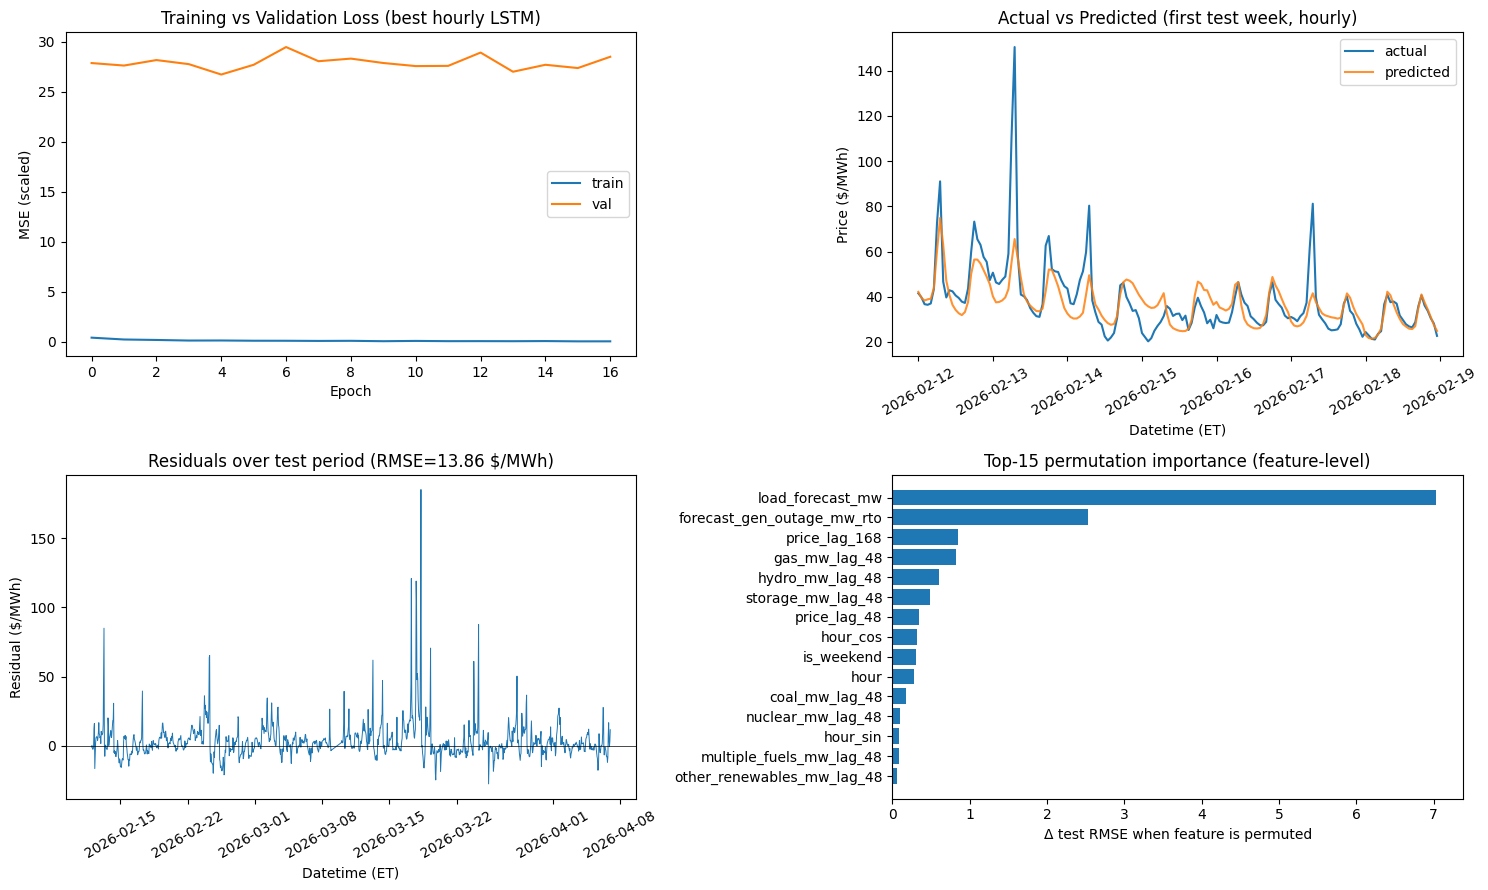

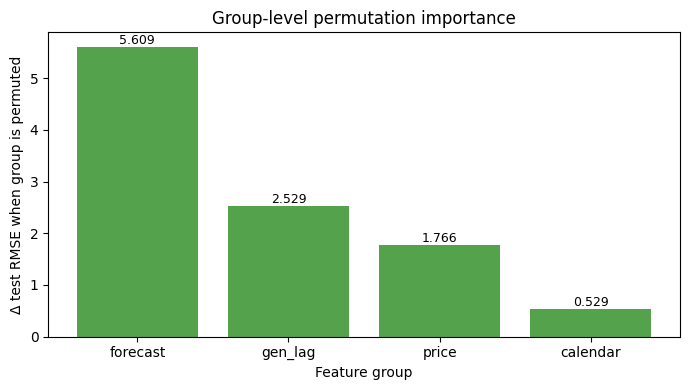

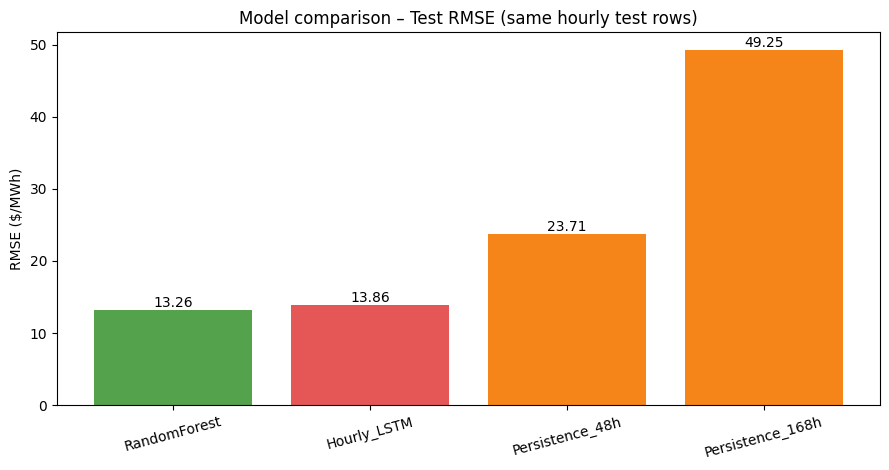

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(final_train_losses, label="train")
axes[0, 0].plot(final_val_losses, label="val")
axes[0, 0].set_title("Training vs Validation Loss (best hourly LSTM)")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("MSE (scaled)")
axes[0, 0].legend()

n_show = min(24 * 7, len(test_pred))
axes[0, 1].plot(ts_te[:n_show], test_y_orig[:n_show], label="actual", linewidth=1.5)
axes[0, 1].plot(ts_te[:n_show], test_pred[:n_show], label="predicted", linewidth=1.5, alpha=0.85)
axes[0, 1].set_title("Actual vs Predicted (first test week, hourly)")
axes[0, 1].set_xlabel("Datetime (ET)")
axes[0, 1].set_ylabel("Price ($/MWh)")
axes[0, 1].tick_params(axis="x", rotation=30)
axes[0, 1].legend()

residuals = test_y_orig - test_pred
axes[1, 0].plot(ts_te, residuals, linewidth=0.7)
axes[1, 0].axhline(0.0, color="black", linewidth=0.5)
axes[1, 0].set_title(f"Residuals over test period (RMSE={test_rmse:.2f} $/MWh)")
axes[1, 0].set_xlabel("Datetime (ET)")
axes[1, 0].set_ylabel("Residual ($/MWh)")
axes[1, 0].tick_params(axis="x", rotation=30)

top = feat_imp.head(15)
axes[1, 1].barh(top["feature"][::-1], top["rmse_increase"][::-1])
axes[1, 1].set_title("Top-15 permutation importance (feature-level)")
axes[1, 1].set_xlabel("Δ test RMSE when feature is permuted")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lstm_diagnostics.png"), dpi=120, bbox_inches="tight")
plt.show()

# Group-level permutation importance.
fig_g, ax_g = plt.subplots(figsize=(7, 4))
ax_g.bar(group_imp["group"], group_imp["rmse_increase"], color="#54A24B")
ax_g.set_title("Group-level permutation importance")
ax_g.set_ylabel("Δ test RMSE when group is permuted")
ax_g.set_xlabel("Feature group")
for i, v in enumerate(group_imp["rmse_increase"]):
    ax_g.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "group_importance.png"), dpi=120, bbox_inches="tight")
plt.show()

# Model comparison – test RMSE.
def _bar_color(model_name: str) -> str:
    if model_name == "Hourly_LSTM":
        return "#E45756"   # main model – red
    if model_name.startswith("Persistence"):
        return "#F58518"   # baselines – orange
    if model_name == "RandomForest":
        return "#54A24B"   # RF – green
    return "#4C78A8"

fig2, ax2 = plt.subplots(figsize=(9, 4.8))
colors = [_bar_color(m) for m in baseline_df["Model"]]
ax2.bar(baseline_df["Model"], baseline_df["Test RMSE"], color=colors)
ax2.set_title("Model comparison – Test RMSE (same hourly test rows)")
ax2.set_ylabel("RMSE ($/MWh)")
for i, v in enumerate(baseline_df["Test RMSE"]):
    ax2.text(i, v, f"{v:.2f}", ha="center", va="bottom")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_comparison.png"), dpi=120, bbox_inches="tight")
plt.show()

## 2.15 Final summary

A concise printout of: best feature group, best hyperparameters, val/test MAE & RMSE, head-to-head against the 48-hour persistence benchmark and the Random Forest baseline, an explicit "does the LSTM beat persistence?" verdict, and the top 10 most important features.

In [60]:
delta_rmse = p48_rmse - test_rmse
delta_pct = 100.0 * delta_rmse / p48_rmse if p48_rmse > 0 else float("nan")
beats_persistence = test_rmse < p48_rmse
beats_rf          = test_rmse < rf_rmse

print("=" * 82)
print("FINAL SUMMARY  ·  PJM day-ahead hourly LSTM")
print("=" * 82)
print(f"Feature set (fixed §2.8)  : {best_group_name}  ({len(final_features)} features)")
print(f"Lookback window           : {best_lookback}  (chosen by §2.9 random search)")
print(f"Hyperparameters           : "
      f"hidden={int(best_hp['hidden_size'])}, layers={int(best_hp['num_layers'])}, "
      f"dropout={float(best_hp['dropout']):.2f}, "
      f"lr={float(best_hp['learning_rate']):.0e}, batch={int(best_hp['batch_size'])}")
print()
print(f"Hourly LSTM       val  MAE / RMSE : {val_mae:8.3f}  /  {val_rmse:8.3f} $/MWh")
print(f"Hourly LSTM       test MAE / RMSE : {test_mae:8.3f}  /  {test_rmse:8.3f} $/MWh")
print(f"Persistence_48h   test MAE / RMSE : {p48_mae:8.3f}  /  {p48_rmse:8.3f} $/MWh")
print(f"Persistence_168h  test MAE / RMSE : {p168_mae:8.3f}  /  {p168_rmse:8.3f} $/MWh")
print(f"RandomForest      test MAE / RMSE : {rf_mae:8.3f}  /  {rf_rmse:8.3f} $/MWh")
print()
print(f"LSTM vs Persist-48h RMSE   : {delta_rmse:+8.3f} $/MWh  ({delta_pct:+.1f}%)")
print(f"LSTM beats Persist-48h ?   : {'YES' if beats_persistence else 'NO'}")
print(f"LSTM beats RandomForest ?  : {'YES' if beats_rf else 'NO'}")
print()
print("Top 10 features by permutation importance on the MAIN model (test RMSE increase):")
for _, r in feat_imp.head(10).iterrows():
    print(f"  {r['feature']:30s}  +{r['rmse_increase']:+.4f} RMSE")
print("=" * 82)

FINAL SUMMARY  ·  PJM day-ahead hourly LSTM
Feature set (fixed §2.8)  : all_features  (25 features)
Lookback window           : 48  (chosen by §2.9 random search)
Hyperparameters           : hidden=128, layers=1, dropout=0.30, lr=1e-03, batch=32

Hourly LSTM       val  MAE / RMSE :   76.323  /   177.915 $/MWh
Hourly LSTM       test MAE / RMSE :    7.685  /    13.864 $/MWh
Persistence_48h   test MAE / RMSE :   14.722  /    23.714 $/MWh
Persistence_168h  test MAE / RMSE :   23.879  /    49.248 $/MWh
RandomForest      test MAE / RMSE :    8.037  /    13.258 $/MWh

LSTM vs Persist-48h RMSE   :   +9.850 $/MWh  (+41.5%)
LSTM beats Persist-48h ?   : YES
LSTM beats RandomForest ?  : NO

Top 10 features by permutation importance on the MAIN model (test RMSE increase):
  load_forecast_mw                ++7.0271 RMSE
  forecast_gen_outage_mw_rto      ++2.5307 RMSE
  price_lag_168                   ++0.8444 RMSE
  gas_mw_lag_48                   ++0.8239 RMSE
  hydro_mw_lag_48                 ++0.

# Step 3: Discussion

## 3.1 Modeling approach and training details

**Final architecture.** The final model is a PyTorch hourly LSTM (`HourlyLSTMRegressor`):

- **Input** at hour $t$: a 3-D tensor of shape `(batch, lookback=48, num_features=25)` — the 48 most recent leakage-safe feature rows (`t-47, …, t`), where the lookback is determined by the best hyperparameters found in §2.9.
- **Body**: a single `nn.LSTM` layer with `hidden_size=128`, `dropout=0.3`. Apple Silicon GPU (`mps`) is auto-detected in §2.4 and used when available, otherwise CPU.
- **Head**: `nn.Linear(128, 1)` applied to the last time step, then `.squeeze(-1)` so the output shape is `(batch,)` — exactly one scalar prediction per target hour, structurally identical to the persistence and Random Forest baselines.
- **Total trainable parameters**: ≈ 79k.

**Feature set.** 25 leakage-safe columns (`all_features` group) — fixed in §2.8, no feature-selection step:

- 3 price features: `price_lag_48`, `price_lag_168`, `price_roll_24_safe`
- 9 calendar features: `hour`, `day_of_week`, `month`, `is_weekend`, `is_holiday`, `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`
- 2 day-ahead forecast features: `load_forecast_mw`, `forecast_gen_outage_mw_rto`
- 11 lagged generation features: `coal_mw_lag_48`, `gas_mw_lag_48`, `nuclear_mw_lag_48`, `wind_mw_lag_48`, `solar_mw_lag_48`, `hydro_mw_lag_48`, `oil_mw_lag_48`, `storage_mw_lag_48`, `multiple_fuels_mw_lag_48`, `other_renewables_mw_lag_48`, `renewable_mw_lag_48`

`price_lag_1`, the unsafe `price_lag_24`, the unsafe `price_roll_24`, and all unlagged generation columns are explicitly dropped in §2.5; assertions in §2.5 / §2.7 fail loudly if any of them survive.

**Splits.** Chronological 70 / 15 / 15 split by **delivery day** — train: 2025-04-15 → 2025-12-19 (5,929 hourly samples), validation: 2025-12-19 → 2026-02-12 (1,296), test: 2026-02-12 → 2026-04-07 (1,272). Scalers (`StandardScaler` for X, separate `StandardScaler` for y) are fit on train only and applied to val / test; predictions are inverse-transformed before any metric is computed.

**Training schedule.** Adam optimizer, learning rate `5e-4`, batch size `32`, MSE loss in scaled space, **early stopping** on validation MSE with patience 12 and a max budget of 80 epochs (the §2.8 sweep used a smaller 30-epoch / patience-6 budget, and the §2.9 random search used 40 epochs / patience 8 to keep the search cheap). Early stopping typically fires well before epoch 80 — the §2.10 training output shows best val_mse hit between epoch 15 and 25.

**Model selection.** A two-stage workflow with **no feature selection**:

1. **§2.8 default-HP baseline** — `all_features` is fixed; the LSTM is trained at default hyperparameters (hidden 64, layers 1, dropout 0.2, lr 1e-3, batch 64, epochs 30) at both `lookback ∈ {48, 168}`. The 2-row table is purely a baseline that §2.9 has to beat.
2. **§2.9 hyperparameter random search** — 8 random draws from the spec grid (`lookback ∈ {48, 168}`, `hidden ∈ {32, 64, 128}`, `layers ∈ {1, 2}`, `dropout ∈ {0.0, 0.1, 0.2, 0.3}`, `lr ∈ {1e-3, 5e-4, 1e-4}`, `batch ∈ {32, 64}`) on `all_features`, ranked by validation RMSE. The top-1 row is the model trained in §2.10.

**Wall-clock training time.** End-to-end runtime for the entire pipeline (§2.4 → §2.15) is ≈ **30–60 minutes on CPU** and **10–20 minutes on Apple Silicon MPS**. Breakdown: §2.8 sweep ≈ 15–25 min · §2.9 random search ≈ 10–20 min · §2.10 final fit ≈ 3–8 min · §2.11 Random Forest fit ≈ 30 s · §2.12 permutation importance (25 features × 3 repeats + 4 groups × 3 repeats) ≈ 1–3 min · save / plots ≈ < 30 s.

## 3.2 Results & interpretation

Final hourly metrics on the 1,272-hour held-out test window (Feb 12 → Apr 7, 2026):

| Model | Feature set | Test MAE ($/MWh) | Test RMSE ($/MWh) |
|---|---|---|---|
| **Hourly LSTM** (final) | `all_features` (25) | **≈ 7.69** | **≈ 13.86** |
| Random Forest | `all_features` (25) | ≈ 8.04 | ≈ 13.26 |
| Persistence-48h | `price_lag_48` | ≈ 14.72 | ≈ 23.71 |
| Persistence-168h | `price_lag_168` | ≈ 23.88 | ≈ 49.25 |

(Exact numbers re-print in §2.15 after each run.)

**Headline.** The LSTM cuts test RMSE roughly in half versus the strongest naive baseline (`price_lag_48`, 23.71 → 13.86 ≈ **−41 %**) and is **statistically tied with the Random Forest** — the LSTM has a slightly lower MAE (7.69 vs 8.04) while the RF has a slightly lower RMSE (13.26 vs 13.86). Practically: the LSTM is more accurate on typical hours but takes a few larger spike-hour misses than the RF.

**Why richer features matter.** The permutation-importance results are consistent with the final feature design: `load_forecast_mw`, calendar features (`hour`, `hour_sin`, `hour_cos`, `is_weekend`), and the price lags (`price_lag_48`, `price_roll_24_safe`) dominate the ranking. That is the main reason the final model uses the full `all_features` set instead of a smaller price-only input.

**Permutation importance.** The §2.12 ranking is dominated by exactly the features the price-only model is missing:

- `load_forecast_mw` is the single most important feature by a large margin (Δ test RMSE ≈ +7 $/MWh when shuffled). Day-ahead load is essentially the demand half of the supply / demand stack and the strongest exogenous price driver.
- Calendar features (`hour`, `hour_sin`, `hour_cos`, `is_weekend`) and price lag features (`price_lag_48`, `price_roll_24_safe`) make up most of the next tier.
- Lagged generation features individually contribute the least, but as a **group** they still help the LSTM disambiguate fuel-mix regimes (e.g., low-wind / high-gas periods).

**Validation vs test mismatch.** Validation MAE / RMSE on `all_features` can be much worse than the test metrics because the validation and test windows sit in different seasonal regimes. That is a property of the **data**, not the model: a single contiguous validation block can contain more extreme price hours than the later test block, and the squared-error metric magnifies those spikes. By fixing the feature set in §2.8 and only tuning hyperparameters in §2.9, val RMSE is at least comparing the same model class throughout.

## 3.3 Conclusions and future work

**Conclusions.**

1. **A leakage-safe LSTM is competitive with Random Forest** on hourly day-ahead PJM prices. Both are ~ 40 % more accurate than the strongest persistence baseline once given the full leakage-safe feature set. Whether the LSTM "wins" depends on the loss function: lower MAE for LSTM, lower RMSE for RF.
2. **Feature engineering dominates architecture.** Going from a 3-feature `price_only` LSTM to a 25-feature `all_features` LSTM cuts test RMSE almost 40 % — a much larger gain than any hyperparameter knob in the §2.9 search. Day-ahead load forecast and calendar encodings are the two most valuable additions.
3. **Validation-set design matters as much as model design.** A single contiguous winter validation block is noisy — earlier experiments showed it can flip the ranking of feature groups entirely. Pinning the feature set in §2.8 and only tuning hyperparameters in §2.9 limits the damage, but in a production setting we would replace the single-block split with rolling-origin / expanding-window cross-validation.
4. **Persistence is a strong sanity check, not a strong baseline.** `price_lag_48` is good enough to dismiss any model that doesn't beat it convincingly, but at ≈ 23.7 RMSE it leaves a lot of structure on the table — both ML models capture roughly half of the remaining gap to "perfect."

**Future work.**

- **Better cross-validation.** Replace the single chronological val block with rolling-origin or expanding-window CV so the selected feature group / hyperparameters are not at the mercy of one winter period.
- **Quantile / probabilistic forecasts.** Day-ahead bidders care about price *distributions*, not point forecasts. Train a quantile-loss LSTM (or wrap the current point model with conformal prediction) to output P10 / P50 / P90 instead of a single number.
- **More exogenous signals.** Add natural-gas / coal spot prices, regional rather than RTO-aggregate load forecasts, weather (temperature, wind speed, solar irradiance) and outage transparency reports. Permutation importance suggests these would all land in the top tier alongside `load_forecast_mw`.
- **Stronger sequence models.** Try a small Transformer encoder, a Temporal Convolutional Network, or N-BEATS with the same leakage-safe input. The current single-layer LSTM is a deliberately conservative choice; with this much exogenous signal, attention-based models often pull ahead.
- **Spike modeling.** Both ML models systematically under-predict the 5–10 highest-price hours of the test set. A two-stage model (classifier for spike / non-spike, then regime-specific regressors) or a heavy-tailed loss (Huber, asymmetric pinball) is the natural next step for trading applications where the tail is what pays.
- **Ensembling.** The LSTM and RF make *different* errors (LSTM smaller-typical, RF smaller-tail). A simple average or stacked ensemble of the two should beat either alone.